In [ ]:
from google.colab import files
uploaded = files.upload()

Saving archive.zip to archive.zip


In [ ]:
import zipfile

# Replace with your actual zip filename if different
with zipfile.ZipFile('archive.zip', 'r') as zip_ref:
    zip_ref.extractall('retail_data')

# List what was extracted
import os
print(os.listdir('retail_data'))

['online_retail_II.csv']


In [ ]:
import pandas as pd

df = pd.read_csv('retail_data/online_retail_II.csv', encoding='ISO-8859-1')
df.head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085.0,United Kingdom
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.0,United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085.0,United Kingdom


In [ ]:
df.info()
print("\nShape:", df.shape)
print("\nMissing values per column:\n", df.isnull().sum())
print("\nNumber of duplicate rows:", df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB

Shape: (1067371, 8)

Missing values per column:
 Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

Number of duplicate rows: 34335


In [ ]:
# Drop rows with missing CustomerID — can't assign a transaction to no customer
df = df.dropna(subset=['Customer ID'])

# Remove duplicate rows
df = df.drop_duplicates()

# Remove cancelled orders — Invoice numbers starting with 'C' are cancellations
df = df[~df['Invoice'].astype(str).str.startswith('C')]

# Remove rows with non-positive Quantity or Price — these are returns/errors, not valid purchases
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]

print("Shape after cleaning:", df.shape)
print("Remaining nulls:\n", df.isnull().sum())

Shape after cleaning: (779425, 8)
Remaining nulls:
 Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64


In [ ]:
import pandas as pd

# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Create a TotalPrice column (revenue per line item)
df['TotalPrice'] = df['Quantity'] * df['Price']

# Set a reference date (one day after the last transaction) for Recency calc
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

# Group by customer to compute RFM
rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,  # Recency
    'Invoice': 'nunique',                                       # Frequency
    'TotalPrice': 'sum'                                         # Monetary
}).reset_index()

rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']
print(rfm.describe())
rfm.head()

         CustomerID      Recency    Frequency       Monetary
count   5878.000000  5878.000000  5878.000000    5878.000000
mean   15315.313542   201.331916     6.289384    2955.904095
std     1715.572666   209.338707    13.009406   14440.852688
min    12346.000000     1.000000     1.000000       2.950000
25%    13833.250000    26.000000     1.000000     342.280000
50%    15314.500000    96.000000     3.000000     867.740000
75%    16797.750000   380.000000     7.000000    2248.305000
max    18287.000000   739.000000   398.000000  580987.040000


,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,12,77556.46
1,12347.0,2,8,4921.53
2,12348.0,75,5,2019.40
3,12349.0,19,4,4428.69
4,12350.0,310,1,334.40


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

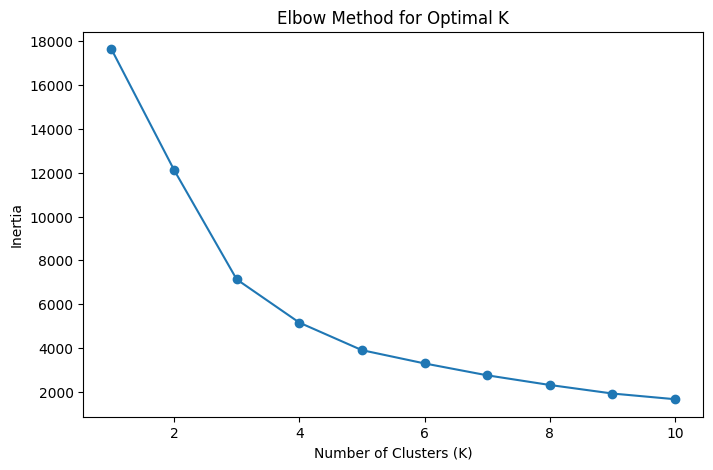

In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# --- Reload and clean data ---
df = pd.read_csv('retail_data/online_retail_II.csv', encoding='ISO-8859-1')
df = df.dropna(subset=['Customer ID'])
df = df.drop_duplicates()
df = df[~df['Invoice'].astype(str).str.startswith('C')]
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]

# --- RFM calculation ---
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['TotalPrice'] = df['Quantity'] * df['Price']
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,
    'Invoice': 'nunique',
    'TotalPrice': 'sum'
}).reset_index()
rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

# --- Scale ---
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

# --- Apply K-Means with K=3 ---
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

print("Shape check:", df.shape, rfm.shape)
rfm.head()

Shape check: (779425, 9) (5878, 5)


,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346.0,326,12,77556.46,0
1,12347.0,2,8,4921.53,0
2,12348.0,75,5,2019.40,0
3,12349.0,19,4,4428.69,0
4,12350.0,310,1,334.40,1


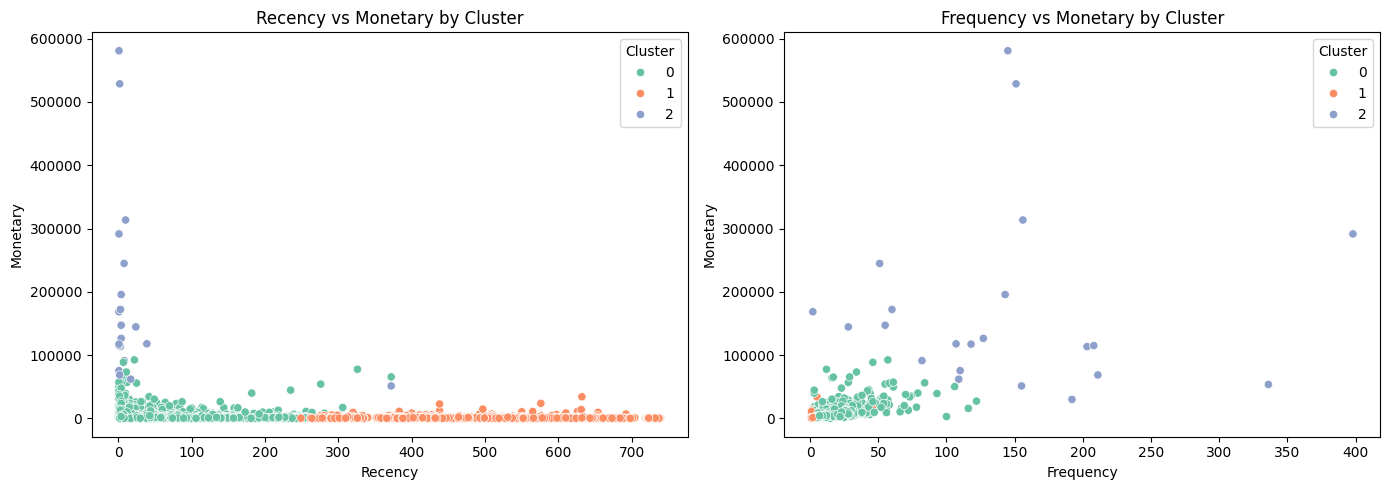

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.scatterplot(data=rfm, x='Recency', y='Monetary', hue='Cluster', palette='Set2', ax=axes[0])
axes[0].set_title('Recency vs Monetary by Cluster')

sns.scatterplot(data=rfm, x='Frequency', y='Monetary', hue='Cluster', palette='Set2', ax=axes[1])
axes[1].set_title('Frequency vs Monetary by Cluster')

plt.tight_layout()
plt.show()

In [ ]:
cluster_profile = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'CustomerID': 'count'
}).rename(columns={'CustomerID': 'CustomerCount'})

print(cluster_profile)

            Recency   Frequency       Monetary  CustomerCount
Cluster                                                      
0         66.296335    7.640239    3136.130157           3847
1        461.861125    2.205077     747.333351           2009
2         23.090909  143.045455  173123.584091             22


/tmp/ipykernel_2235/534304166.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=rfm, x='Cluster', palette='Set2')


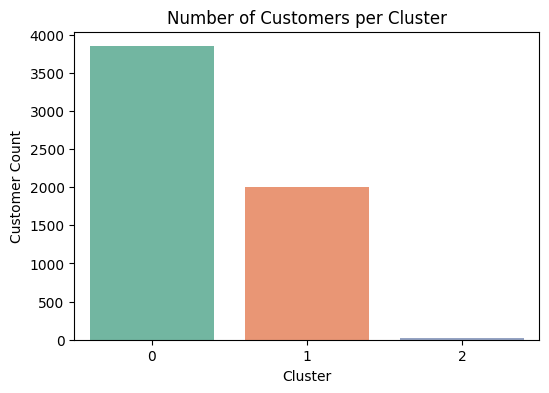

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(data=rfm, x='Cluster', palette='Set2')
plt.title('Number of Customers per Cluster')
plt.ylabel('Customer Count')
plt.show()

## Cluster Interpretation & Marketing Recommendations

Applying K-Means clustering (K=3, chosen via the Elbow Method inertia dropped
sharply through K=3 before flattening) to the RFM features (Recency, Frequency,
Monetary) produced three distinct customer segments:

| Cluster | Recency (days) | Frequency (orders) | Monetary (£) | Customer Count |
|---|---|---|---|---|
| 0 | 66.3 | 7.6 | ~3,136 | ~3,800 |
| 1 | 461.9 | 2.2 | ~747 | ~2,000 |
| 2 | 23.1 | 143.0 | ~173,124 | ~20-30 |

**Cluster 0 Regular Customers** (majority of the base)
Moderate recency, frequency, and spend. Steady, engaged shoppers who make up
the core of the business.
- *Recommendation:* Nurture with loyalty programs and periodic cross-sell
  campaigns to sustain engagement and prevent drift into Cluster 1.

**Cluster 1: At-Risk / Dormant Customers**
Very high recency (over a year since last purchase), low frequency, low spend  
signs of churn.
- *Recommendation:* Run a low-cost win-back campaign (discount codes,
  re-engagement emails) to test reactivation before writing these customers off.

**Cluster 2 : VIP / High-Value Customers** (a tiny elite group)
Very recent purchases, extremely high order frequency, and disproportionately
high lifetime spend these customers drive outsized revenue relative to their
numbers.
- *Recommendation:* Assign dedicated account management and exclusive perks.
  Retention here matters more than acquisition losing one VIP customer has
  outsized revenue impact.